# MLP PyTorch: Random Forest e Rede Neural

Etapa 2: Modelagem com Redes Neurais. Comparação da MLP (PyTorch) com baselines lineares (Etapa 1) e um modelo ensemble (Random Forest).

| Modelo | Tipo | Seção |
|---|---|---|
| `RandomForestClassifier` | Ensemble (árvores) | 3 |
| `ChurnMLP` (PyTorch) | Rede neural | 4 |

**Métricas:** AUC-ROC, PR-AUC, Recall (churn), F1 (churn), Precisão (churn)  
**Validação:** Random Forest → StratifiedKFold (5 folds); MLP → split 70/15/15 com early stopping  
**Tracking:** MLflow com backend SQLite local (mesmo experimento dos baselines)

## 1. Setup

In [1]:
import logging
import pathlib
import random
import subprocess
import warnings

import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from mlflow.models import infer_signature
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

# force=True é necessário porque `import mlflow.pytorch` adiciona um handler ao root
# logger e seta o nível para ERROR antes deste basicConfig ser chamado; sem force,
# a chamada é no-op e log.info() é descartado silenciosamente.
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)
log = logging.getLogger(__name__)

SEED = 42
DATA_PATH = "../data/raw/telco-churn.csv"
MLFLOW_URI = "sqlite:///../mlruns.db"
EXPERIMENT_NAME = "telco-churn"
N_FOLDS = 5
THRESHOLD = 0.4

# Seeds fixados para reprodutibilidade total
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

plt.rcParams["figure.figsize"] = (10, 4)
sns.set_theme(style="whitegrid")

log.info("Setup concluído. SEED=%d, FOLDS=%d, THRESHOLD=%.1f", SEED, N_FOLDS, THRESHOLD)

20:28:48 | INFO | Setup concluído. SEED=42, FOLDS=5, THRESHOLD=0.4


## 2. Dados

Mesmo carregamento e pré-processamento do notebook 02-baselines. Após o pré-processamento, realiza split estratificado 70/15/15 para o treinamento da MLP com early stopping.

**Por que split fixo para a MLP?** A MLP (PyTorch) precisa de um conjunto de validação separado para monitorar overfitting e ativar o early stopping. O Random Forest continua usando validação cruzada estratificada (mesma estratégia do notebook 02).

In [2]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

# Correções identificadas na EDA
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df["Churn"] = (df["Churn"] == "Yes").astype(int)

# Remover ID: não é feature preditiva
df = df.drop(columns=["customerID"])

log.info("Dataset carregado: %s", df.shape)
log.info("Churn rate: %.1f%%", df["Churn"].mean() * 100)

20:28:48 | INFO | Dataset carregado: (7043, 20)
20:28:48 | INFO | Churn rate: 26.5%


In [3]:
TARGET = "Churn"
X = df.drop(columns=[TARGET])
y = df[TARGET]

# TotalCharges removida: colinearidade com tenure (r=+0.83) sem sinal independente
# gender e PhoneService removidas: Cramér's V ≈ 0 com o target
LOW_SIGNAL = ["gender", "PhoneService", "TotalCharges"]
X = X.drop(columns=LOW_SIGNAL)

# Interaction terms: Contract × tenure para cada tipo de contrato
X["monthly_x_tenure"]  = (X["Contract"] == "Month-to-month").astype(int) * X["tenure"]
X["one_year_x_tenure"] = (X["Contract"] == "One year").astype(int)       * X["tenure"]
X["two_year_x_tenure"] = (X["Contract"] == "Two year").astype(int)       * X["tenure"]

# tenure removido: completamente codificado nas três interações acima
X = X.drop(columns=["tenure"])

num_features = ["MonthlyCharges", "monthly_x_tenure", "one_year_x_tenure", "two_year_x_tenure"]
cat_features = [c for c in X.columns if c not in num_features]

print(f"Features numéricas ({len(num_features)}): {num_features}")
print(f"Features categóricas ({len(cat_features)}): {cat_features}")
print(f"Total de features: {X.shape[1]}")

Features numéricas (4): ['MonthlyCharges', 'monthly_x_tenure', 'one_year_x_tenure', 'two_year_x_tenure']
Features categóricas (14): ['SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Total de features: 18


In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            num_features,
        ),
        (
            "cat",
            OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False),
            cat_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

log.info("Preprocessor definido: %d features numéricas, %d categóricas", len(num_features), len(cat_features))

20:28:48 | INFO | Preprocessor definido: 4 features numéricas, 14 categóricas


In [5]:
# Split 70/15/15 estratificado, usado exclusivamente para a MLP
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, stratify=y_temp, random_state=SEED
)

log.info(
    "Splits: train=%d (%.1f%% churn), val=%d (%.1f%% churn), test=%d (%.1f%% churn)",
    len(X_train), y_train.mean() * 100,
    len(X_val),   y_val.mean()   * 100,
    len(X_test),  y_test.mean()  * 100,
)

20:28:48 | INFO | Splits: train=4929 (26.5% churn), val=1057 (26.6% churn), test=1057 (26.5% churn)


In [6]:
# Preprocessor: fit apenas no treino, transform no val e test
preprocessor.fit(X_train)
X_train_t = preprocessor.transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)

log.info("Shapes pós-transformação: train=%s, val=%s, test=%s",
         X_train_t.shape, X_val_t.shape, X_test_t.shape)
print(f"Número de features após OHE: {X_train_t.shape[1]}")

20:28:49 | INFO | Shapes pós-transformação: train=(4929, 39), val=(1057, 39), test=(1057, 39)


Número de features após OHE: 39


In [7]:
def to_tensor(X_arr, y_series):
    """Converte array numpy e Series pandas para tensores PyTorch."""
    X_t = torch.tensor(X_arr, dtype=torch.float32)
    y_t = torch.tensor(y_series.values, dtype=torch.float32).unsqueeze(1)
    return X_t, y_t


X_train_pt, y_train_pt = to_tensor(X_train_t, y_train)
X_val_pt,   y_val_pt   = to_tensor(X_val_t,   y_val)
X_test_pt,  y_test_pt  = to_tensor(X_test_t,  y_test)

log.info(
    "Tensores criados: X_train=%s, X_val=%s, X_test=%s",
    tuple(X_train_pt.shape), tuple(X_val_pt.shape), tuple(X_test_pt.shape),
)
print(f"dtype X: {X_train_pt.dtype} | dtype y: {y_train_pt.dtype}")

20:28:49 | INFO | Tensores criados: X_train=(4929, 39), X_val=(1057, 39), X_test=(1057, 39)


dtype X: torch.float32 | dtype y: torch.float32


In [8]:
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT_NAME)
mlflow.sklearn.autolog(disable=True)

mlflow_dataset = mlflow.data.from_pandas(
    df,
    source=DATA_PATH,
    name="telco-churn",
    targets="Churn",
)

try:
    GIT_COMMIT = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
    ).decode().strip()
except Exception:
    GIT_COMMIT = "unknown"

log.info("MLflow tracking URI: %s", MLFLOW_URI)
log.info("Experimento: %s", EXPERIMENT_NAME)
log.info("Git commit: %s", GIT_COMMIT)
print(f"MLflow UI: mlflow ui --backend-store-uri {MLFLOW_URI}")

20:28:49 | INFO | MLflow tracking URI: sqlite:///../mlruns.db
20:28:49 | INFO | Experimento: telco-churn
20:28:49 | INFO | Git commit: 5c92795


MLflow UI: mlflow ui --backend-store-uri sqlite:///../mlruns.db


## 3. Random Forest

`RandomForestClassifier` com `class_weight='balanced'` para compensar o desbalanceamento de classes.  
Avaliado com `StratifiedKFold` (5 folds) sobre o **dataset completo**, exatamente como os baselines do notebook 02.

O split 70/15/15 é reservado exclusivamente para a MLP, pois o Random Forest não precisa de val set: o CV já estima o desempenho fora da amostra.

In [9]:
CV = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)


def _make_threshold_scorer(metric_fn):
    """Retorna scorer com assinatura (estimator, X, y) usando threshold customizado."""
    def scorer(estimator, X, y):
        proba = estimator.predict_proba(X)[:, 1]
        y_pred = (proba >= THRESHOLD).astype(int)
        return metric_fn(y, y_pred, zero_division=0)
    return scorer


recall_t04    = _make_threshold_scorer(recall_score)
f1_t04        = _make_threshold_scorer(f1_score)
precision_t04 = _make_threshold_scorer(precision_score)


def evaluate_cv(pipeline, X, y, model_name):
    """Avalia pipeline com cross-validation estratificado. Retorna (métricas_resumo, cv_results_brutos)."""
    log.info("Avaliando '%s' com %d folds (threshold=%.1f)...", model_name, N_FOLDS, THRESHOLD)

    scoring = {
        "roc_auc": "roc_auc",
        "average_precision": "average_precision",
        "recall": recall_t04,
        "f1": f1_t04,
        "precision": precision_t04,
    }

    cv_results = cross_validate(
        pipeline,
        X,
        y,
        cv=CV,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1,
    )

    metrics = {
        "roc_auc_mean": float(cv_results["test_roc_auc"].mean()),
        "roc_auc_std": float(cv_results["test_roc_auc"].std()),
        "pr_auc_mean": float(cv_results["test_average_precision"].mean()),
        "pr_auc_std": float(cv_results["test_average_precision"].std()),
        "recall_mean": float(np.nan_to_num(cv_results["test_recall"].mean())),
        "recall_std": float(np.nan_to_num(cv_results["test_recall"].std())),
        "f1_mean": float(np.nan_to_num(cv_results["test_f1"].mean())),
        "f1_std": float(np.nan_to_num(cv_results["test_f1"].std())),
        "precision_mean": float(np.nan_to_num(cv_results["test_precision"].mean())),
        "precision_std": float(np.nan_to_num(cv_results["test_precision"].std())),
    }

    log.info(
        "%s → AUC-ROC=%.3f | PR-AUC=%.3f | Recall=%.3f | F1=%.3f | Precision=%.3f",
        model_name,
        metrics["roc_auc_mean"],
        metrics["pr_auc_mean"],
        metrics["recall_mean"],
        metrics["f1_mean"],
        metrics["precision_mean"],
    )
    return metrics, cv_results

In [10]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            num_features,
        ),
        (
            "cat",
            OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False),
            cat_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

rf_pipe = Pipeline([
    ("preprocessor", rf_preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=SEED,
        ),
    ),
])

rf_metrics, rf_cv = evaluate_cv(rf_pipe, X, y, "Random Forest")

params_rf = {
    "model": "RandomForestClassifier",
    "n_estimators": 100,
    "max_depth": None,
    "class_weight": "balanced",
    "threshold": THRESHOLD,
    "n_folds": N_FOLDS,
    "seed": SEED,
}

# Treina no dataset completo para salvar o artefato e inferir a assinatura
rf_pipe.fit(X, y)
signature_rf = mlflow.models.infer_signature(X, rf_pipe.predict_proba(X)[:, 1])

with mlflow.start_run(run_name="random-forest-balanced"):
    mlflow.set_tags({"stage": "candidate", "model_type": "ensemble", "git_commit": GIT_COMMIT})
    mlflow.log_input(mlflow_dataset, context="training")
    mlflow.log_params(params_rf)
    mlflow.log_metrics(rf_metrics)
    for fold_idx, val in enumerate(rf_cv["test_roc_auc"]):
        mlflow.log_metric("roc_auc_fold", val, step=fold_idx)
    for fold_idx, val in enumerate(rf_cv["test_average_precision"]):
        mlflow.log_metric("pr_auc_fold", val, step=fold_idx)
    mlflow.sklearn.log_model(
        rf_pipe,
        name="model",
        input_example=X.head(3),
        signature=signature_rf,
    )
    run_id_rf = mlflow.active_run().info.run_id

log.info("Run registrado: %s", run_id_rf)

20:28:49 | INFO | Avaliando 'Random Forest' com 5 folds (threshold=0.4)...
20:28:59 | INFO | Random Forest → AUC-ROC=0.809 | PR-AUC=0.586 | Recall=0.601 | F1=0.579 | Precision=0.558
2026/05/03 20:29:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
20:29:03 | INFO | Run registrado: faf448eab8994ae38bc991144cf54110


## 4. MLP (PyTorch)

Rede neural `ChurnMLP` com duas camadas ocultas (64 → 32 → 1), ReLU e Dropout.

**Decisões de design:**
- `BCEWithLogitsLoss` com `pos_weight` para compensar desbalanceamento de classes (mesmo princípio do `class_weight='balanced'` do sklearn)
- Early stopping com paciência de 10 épocas para evitar overfitting
- Adam com weight decay (L2 regularization) para generalização
- Threshold 0.4: mesmo threshold dos baselines, priorizando recall

**Avaliação:** conjunto de teste fixo (15% do dataset), separado antes do treinamento.

In [11]:
class ChurnMLP(nn.Module):
    """MLP para classificação binária de churn.

    Arquitetura: Linear(n_features, 64) → ReLU → Dropout
                 → Linear(64, 32) → ReLU → Dropout
                 → Linear(32, 1)  (logit)
    """

    def __init__(self, n_features: int, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32),         nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


n_features = X_train_t.shape[1]
model = ChurnMLP(n_features=n_features, dropout=0.3)

log.info("Arquitetura MLP: %d features → 64 → 32 → 1", n_features)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal de parâmetros: {total_params:,}")

20:29:03 | INFO | Arquitetura MLP: 39 features → 64 → 32 → 1


ChurnMLP(
  (net): Sequential(
    (0): Linear(in_features=39, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total de parâmetros: 4,673


In [12]:
# pos_weight: compensa o desbalanceamento de classes na loss
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

log.info(
    "Classe positiva (churn): %d amostras | Negativa: %d | pos_weight=%.2f",
    n_pos, n_neg, pos_weight.item(),
)
print(f"pos_weight: {pos_weight.item():.3f} (n_neg/n_pos = {n_neg}/{n_pos})")

20:29:04 | INFO | Classe positiva (churn): 1308 amostras | Negativa: 3621 | pos_weight=2.77


pos_weight: 2.768 (n_neg/n_pos = 3621/1308)


In [13]:
BATCH_SIZE = 64
MAX_EPOCHS = 100
PATIENCE   = 10

train_ds = TensorDataset(X_train_pt, y_train_pt)
_g = torch.Generator()
_g.manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=_g)

log.info(
    "DataLoader: %d amostras, batch_size=%d → %d batches/época",
    len(train_ds), BATCH_SIZE, len(train_loader),
)

20:29:04 | INFO | DataLoader: 4929 amostras, batch_size=64 → 78 batches/época


In [ ]:
params_mlp = {
    "model": "MLP",
    "hidden_dims": "64-32",
    "dropout_rate": 0.3,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "pos_weight": float(pos_weight.item()),
    "threshold": THRESHOLD,
    "train_size": len(X_train),
    "val_size": len(X_val),
    "test_size": len(X_test),
    "seed": SEED,
}

best_val_loss     = float("inf")
best_epoch_idx    = 0
epochs_no_improve = 0
best_weights      = None
train_losses      = []
val_losses        = []

with mlflow.start_run(run_name="mlp-base") as run:
    mlflow.set_tags({"stage": "candidate", "model_type": "neural_network", "git_commit": GIT_COMMIT})
    mlflow.log_input(mlflow_dataset, context="training")
    mlflow.log_params(params_mlp)

    # --- Loop de treinamento com early stopping ---
    for epoch in range(MAX_EPOCHS):
        # Treino
        model.train()
        batch_losses = []
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = float(np.mean(batch_losses))

        # Validação
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_pt)
            val_loss   = criterion(val_logits, y_val_pt).item()
            val_proba  = torch.sigmoid(val_logits).numpy().ravel()
            val_auc    = roc_auc_score(y_val, val_proba)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("val_loss",   val_loss,   step=epoch)
        mlflow.log_metric("val_roc_auc", val_auc,   step=epoch)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            best_epoch_idx    = epoch
            epochs_no_improve = 0
            best_weights      = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                log.info("Early stopping na época %d (paciência=%d)", epoch + 1, PATIENCE)
                break

    if best_weights is not None:
        model.load_state_dict(best_weights)
    log.info("Treinamento concluído. Melhor época: %d | Melhor val_loss: %.4f", best_epoch_idx, best_val_loss)

    # --- Avaliação no conjunto de teste ---
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_pt)
        test_proba  = torch.sigmoid(test_logits).numpy().ravel()
        test_pred   = (test_proba >= THRESHOLD).astype(int)

    mlp_metrics = {
        "roc_auc":  roc_auc_score(y_test, test_proba),
        "pr_auc":   average_precision_score(y_test, test_proba),
        "recall":   recall_score(y_test, test_pred),
        "f1":       f1_score(y_test, test_pred),
        "precision": precision_score(y_test, test_pred, zero_division=0),
        "best_epoch": float(best_epoch_idx),
        "best_val_loss": float(best_val_loss),
    }
    mlflow.log_metrics(mlp_metrics)

    log.info(
        "MLP (teste) → AUC-ROC=%.3f | PR-AUC=%.3f | Recall=%.3f | F1=%.3f | Precision=%.3f",
        mlp_metrics["roc_auc"], mlp_metrics["pr_auc"],
        mlp_metrics["recall"],  mlp_metrics["f1"], mlp_metrics["precision"],
    )

    # --- Artefato 1: curva de treinamento ---
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train_losses, label="train_loss", color="steelblue")
    ax.plot(val_losses,   label="val_loss",   color="tomato")
    ax.axvline(
        best_epoch_idx, color="green", linestyle="--", alpha=0.7,
        label=f"best epoch ({best_epoch_idx})",
    )
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss")
    ax.set_title("Curva de Treinamento da MLP (BCEWithLogitsLoss)")
    ax.legend()
    plt.tight_layout()
    mlflow.log_figure(fig, "mlp_training_curve.png")
    plt.show()

    # --- Artefato 2: pesos do melhor checkpoint ---
    models_dir = pathlib.Path("../models")
    models_dir.mkdir(exist_ok=True)
    checkpoint_path = models_dir / "mlp_best.pt"
    torch.save(model.state_dict(), checkpoint_path)
    mlflow.log_artifact(str(checkpoint_path), artifact_path="checkpoints")
    log.info("Checkpoint salvo em %s", checkpoint_path)

    # --- Artefato 3: modelo PyTorch com assinatura ---
    signature = infer_signature(X_test_t[:3], test_proba[:3])
    mlflow.pytorch.log_model(
        model,
        name="model",
        input_example=X_test_t[:3],
        signature=signature,
    )

    # --- Artefato 4: notebook como artefato ---
    notebook_path = pathlib.Path("03-mlp.ipynb")
    if notebook_path.exists():
        mlflow.log_artifact(str(notebook_path))
        log.info("Notebook logado como artefato no MLflow")

    run_id_mlp = run.info.run_id

log.info("Run MLP registrado: %s", run_id_mlp)

### 4.1 Experimentos de Otimização da MLP

Dois experimentos para tentar melhorar as métricas (especialmente Precisão e F1) sem alterar os dados ou o threshold:

| Experimento | Mudança em relação ao modelo base | Hipótese |
|---|---|---|
| **BatchNorm (64→32)** | Batch Normalization antes de cada ReLU | Estabiliza gradientes, pode acelerar e melhorar a convergência |
| **Arquitetura maior (128→64→32)** | Mais neurônios + BN + dropout escalonado + LR menor | Maior capacidade de representação com regularização adequada |

Ambos mantêm o mesmo split de dados, `pos_weight`, threshold e protocolo de early stopping para comparação direta.

In [15]:
def _train_evaluate_mlp(model, optimizer, run_name, extra_params=None):
    """Treina model com early stopping e avalia no test set. Registra no MLflow.

    Reutiliza: train_ds, X_val_pt, y_val_pt, y_val, X_test_pt, y_test,
               criterion, BATCH_SIZE, MAX_EPOCHS, PATIENCE, THRESHOLD, SEED.
    Retorna: (metrics_dict, train_losses, val_losses, best_epoch_idx)
    """
    _g = torch.Generator()
    _g.manual_seed(SEED)
    # drop_last=True evita batch de tamanho 1 no final, que quebra o BatchNorm
    _loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=_g, drop_last=True)

    best_val_loss, best_epoch_idx, epochs_no_improve = float("inf"), 0, 0
    best_weights = None
    train_losses, val_losses = [], []

    params = {
        "hidden_dims": "?", "batch_norm": False, "dropout_rate": 0.3,
        "learning_rate": 1e-3, "weight_decay": 1e-4,
        "batch_size": BATCH_SIZE, "max_epochs": MAX_EPOCHS, "patience": PATIENCE,
        "pos_weight": float(pos_weight.item()), "threshold": THRESHOLD, "seed": SEED,
        **(extra_params or {}),
    }

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tags({"stage": "experiment", "model_type": "neural_network", "git_commit": GIT_COMMIT})
        mlflow.log_input(mlflow_dataset, context="training")
        mlflow.log_params(params)

        for epoch in range(MAX_EPOCHS):
            model.train()
            batch_losses = []
            for X_batch, y_batch in _loader:
                optimizer.zero_grad()
                loss = criterion(model(X_batch), y_batch)
                loss.backward()
                optimizer.step()
                batch_losses.append(loss.item())
            train_loss = float(np.mean(batch_losses))

            model.eval()
            with torch.no_grad():
                val_logits = model(X_val_pt)
                val_loss   = criterion(val_logits, y_val_pt).item()
                val_auc    = roc_auc_score(y_val, torch.sigmoid(val_logits).numpy().ravel())

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            mlflow.log_metric("train_loss",  train_loss, step=epoch)
            mlflow.log_metric("val_loss",    val_loss,   step=epoch)
            mlflow.log_metric("val_roc_auc", val_auc,    step=epoch)

            if val_loss < best_val_loss:
                best_val_loss, best_epoch_idx, epochs_no_improve = val_loss, epoch, 0
                best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= PATIENCE:
                    log.info("Early stopping na época %d", epoch + 1)
                    break

        if best_weights:
            model.load_state_dict(best_weights)
        log.info("Concluído. Melhor época: %d | val_loss: %.4f", best_epoch_idx, best_val_loss)

        model.eval()
        with torch.no_grad():
            test_proba = torch.sigmoid(model(X_test_pt)).numpy().ravel()
        test_pred = (test_proba >= THRESHOLD).astype(int)

        metrics = {
            "roc_auc":       roc_auc_score(y_test, test_proba),
            "pr_auc":        average_precision_score(y_test, test_proba),
            "recall":        recall_score(y_test, test_pred),
            "f1":            f1_score(y_test, test_pred),
            "precision":     precision_score(y_test, test_pred, zero_division=0),
            "best_epoch":    float(best_epoch_idx),
            "best_val_loss": float(best_val_loss),
        }
        mlflow.log_metrics(metrics)
        log.info(
            "%s → AUC-ROC=%.3f | PR-AUC=%.3f | Recall=%.3f | F1=%.3f | Precisão=%.3f",
            run_name, metrics["roc_auc"], metrics["pr_auc"],
            metrics["recall"], metrics["f1"], metrics["precision"],
        )
        mlflow.pytorch.log_model(model, name="model")

    return metrics, train_losses, val_losses, best_epoch_idx

In [16]:
class ChurnMLPBatchNorm(nn.Module):
    """MLP 64→32 com Batch Normalization antes de cada ReLU.

    Mesma arquitetura base, acrescentando BN para estabilizar gradientes.
    """

    def __init__(self, n_features: int, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32),         nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


torch.manual_seed(SEED)
model_bn = ChurnMLPBatchNorm(n_features=n_features, dropout=0.3)
optimizer_bn = torch.optim.Adam(model_bn.parameters(), lr=1e-3, weight_decay=1e-4)

log.info("Experimento 1: Batch Normalization na arquitetura 64->32")
metrics_bn, _, _, _ = _train_evaluate_mlp(
    model_bn,
    optimizer_bn,
    run_name="mlp-batchnorm",
    extra_params={"model": "MLP-BatchNorm", "hidden_dims": "64-32", "batch_norm": True},
)

20:29:10 | INFO | Experimento 1: Batch Normalization na arquitetura 64->32
20:29:13 | INFO | Early stopping na época 14
20:29:13 | INFO | Concluído. Melhor época: 3 | val_loss: 0.7558
20:29:13 | INFO | mlp-batchnorm → AUC-ROC=0.843 | PR-AUC=0.630 | Recall=0.889 | F1=0.594 | Precisão=0.445
2026/05/03 20:29:13 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


In [17]:
class ChurnMLPLarge(nn.Module):
    """MLP 128→64→32 com BatchNorm e dropout escalonado para maior capacidade."""

    def __init__(self, n_features: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 64),         nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, 32),          nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


torch.manual_seed(SEED)
model_large = ChurnMLPLarge(n_features=n_features)
optimizer_large = torch.optim.Adam(model_large.parameters(), lr=5e-4, weight_decay=1e-4)

log.info("Experimento 2: Arquitetura maior 128->64->32 com BatchNorm e dropout escalonado")
metrics_large, _, _, _ = _train_evaluate_mlp(
    model_large,
    optimizer_large,
    run_name="mlp-large",
    extra_params={
        "model":         "MLP-Large",
        "hidden_dims":   "128-64-32",
        "batch_norm":    True,
        "dropout_rate":  "0.4-0.4-0.3",
        "learning_rate": 5e-4,
    },
)

20:29:16 | INFO | Experimento 2: Arquitetura maior 128->64->32 com BatchNorm e dropout escalonado
20:29:20 | INFO | Early stopping na época 16
20:29:20 | INFO | Concluído. Melhor época: 5 | val_loss: 0.7621
20:29:20 | INFO | mlp-large → AUC-ROC=0.843 | PR-AUC=0.624 | Recall=0.936 | F1=0.583 | Precisão=0.423
2026/05/03 20:29:20 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


In [18]:
# Seleciona a melhor variante pelo menor val_loss (critério de validação: evita
# usar o test set para a decisão de arquitetura, o que seria contaminação).
# best_val_loss é o val_loss do melhor checkpoint registrado pelo early stopping.
mlp_variants = {
    "MLP Base (64→32)":        mlp_metrics,
    "MLP BatchNorm (64→32)":   metrics_bn,
    "MLP Large (128→64→32)":   metrics_large,
}

print(f"{'='*65}")
print(f"COMPARAÇÃO DE VARIANTES DA MLP (threshold={THRESHOLD})")
print(f"{'='*65}")
rows_variants = []
for name, m in mlp_variants.items():
    rows_variants.append({
        "Variante":       name,
        "AUC-ROC":        f"{m['roc_auc']:.3f}",
        "PR-AUC":         f"{m['pr_auc']:.3f}",
        "Recall":         f"{m['recall']:.3f}",
        "F1":             f"{m['f1']:.3f}",
        "Precisão":       f"{m['precision']:.3f}",
        "Best Val Loss":  f"{m['best_val_loss']:.4f}",
    })
display(pd.DataFrame(rows_variants).set_index("Variante"))

# Seleção pelo critério de validação (não pelo test set)
best_variant_name = min(mlp_variants, key=lambda k: mlp_variants[k]["best_val_loss"])
mlp_metrics = mlp_variants[best_variant_name]
log.info(
    "Melhor variante: %s | best_val_loss=%.4f | PR-AUC=%.3f | Precisão=%.3f",
    best_variant_name, mlp_metrics["best_val_loss"], mlp_metrics["pr_auc"], mlp_metrics["precision"],
)
print(f"\nMelhor variante selecionada: {best_variant_name}")
print(f"→ Critério: menor val_loss no conjunto de validação (early stopping).")
print(f"→ mlp_metrics atualizado: seção 5 usará esse resultado.")

COMPARAÇÃO DE VARIANTES DA MLP (threshold=0.4)


,AUC-ROC,PR-AUC,Recall,F1,Precisão,Best Val Loss
Variante,,,,,,
MLP Base (64→32),0.848,0.633,0.886,0.597,0.450,0.7455
MLP BatchNorm (64→32),0.843,0.630,0.889,0.594,0.445,0.7558
MLP Large (128→64→32),0.843,0.624,0.936,0.583,0.423,0.7621


20:29:23 | INFO | Melhor variante: MLP Base (64→32) | best_val_loss=0.7455 | PR-AUC=0.633 | Precisão=0.450



Melhor variante selecionada: MLP Base (64→32)
→ Critério: menor val_loss no conjunto de validação (early stopping).
→ mlp_metrics atualizado: seção 5 usará esse resultado.


## 5. Tabela Comparativa de Resultados

Comparação entre todos os modelos treinados até aqui. Baselines da Etapa 1 (DummyClassifier, Logistic Regression) são incluídos para referência.

> **Nota metodológica da comparação RF vs. MLP:**
>
> - **Random Forest e baselines** foram avaliados via `StratifiedKFold` (5 folds) **sobre o dataset completo** (incluindo as amostras do test set da MLP). As métricas reportadas são médias ± desvio padrão entre folds.
> - **MLP** é avaliada em um conjunto de teste fixo e exclusivo (15% do dataset, separado antes de qualquer treinamento). A métrica é um único ponto estimado, sem desvio padrão.
>
> Por isso, **duas fontes de incomparabilidade** existem:
> 1. **Diferença de protocolo:** média de CV vs. ponto único, a variância do RF está exposta, a da MLP não.
> 2. **Overlap nos dados:** o CV do RF eventualmente treinou em exemplos que compõem o test set da MLP (quando esses exemplos caíram no fold de treino). Isso não é data leakage clássico, mas significa que as médias do CV do RF não são uma estimativa "no mesmo holdout" que a MLP usa.
>
> Usar CV no RF mantém consistência com a Etapa 1 e produz uma estimativa mais robusta do que um único split. A comparação deve ser lida como **indicativa**, não como um ranking estatisticamente rigoroso.

In [19]:
# Importar métricas dos baselines (Etapa 1) do MLflow
client = mlflow.MlflowClient()

_exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if _exp is None:
    log.warning("Experimento '%s' não encontrado no MLflow. Execute o notebook 02-baselines.ipynb primeiro.", EXPERIMENT_NAME)
    runs = []
else:
    runs = client.search_runs(
        experiment_ids=[_exp.experiment_id],
        filter_string="",
        order_by=["start_time ASC"],
    )

# Mapeia run_name → métricas (mantém apenas o run mais recente de cada nome)
runs_by_name = {}
for _run in runs:
    _name = _run.data.tags.get("mlflow.runName", _run.info.run_id)
    runs_by_name[_name] = _run.data.metrics

log.info("Runs encontrados: %s", list(runs_by_name.keys()))

# Nomes dos runs de baseline conforme registrados no notebook 02-baselines
BASELINE_RUNS = {
    "Dummy (most_frequent)": "dummy-most_frequent",
    "Dummy (stratified)":    "dummy-stratified",
    "Logistic Regression":   "logistic-regression-balanced",
}

TARGETS = {
    "AUC-ROC":  0.80,
    "PR-AUC":   0.60,
    "Recall":   0.70,
    "F1":       0.60,
    "Precisão": 0.55,
}


def fmt_cv(m, mean_key, std_key):
    """Formata métrica de CV como 'mean ± std'."""
    mean = m.get(mean_key, float("nan"))
    std  = m.get(std_key,  float("nan"))
    return f"{mean:.3f} ± {std:.3f}"


rows = []

# Baselines da Etapa 1: CV (mean ± std disponíveis no MLflow)
for display_name, run_name in BASELINE_RUNS.items():
    m = runs_by_name.get(run_name, {})
    rows.append({
        "Modelo":   display_name,
        "AUC-ROC":  fmt_cv(m, "roc_auc_mean",   "roc_auc_std"),
        "PR-AUC":   fmt_cv(m, "pr_auc_mean",    "pr_auc_std"),
        "Recall":   fmt_cv(m, "recall_mean",    "recall_std"),
        "F1":       fmt_cv(m, "f1_mean",        "f1_std"),
        "Precisão": fmt_cv(m, "precision_mean", "precision_std"),
    })

# Random Forest: CV (mean ± std calculados neste notebook)
rows.append({
    "Modelo":   "Random Forest",
    "AUC-ROC":  f"{rf_metrics['roc_auc_mean']:.3f} ± {rf_metrics['roc_auc_std']:.3f}",
    "PR-AUC":   f"{rf_metrics['pr_auc_mean']:.3f} ± {rf_metrics['pr_auc_std']:.3f}",
    "Recall":   f"{rf_metrics['recall_mean']:.3f} ± {rf_metrics['recall_std']:.3f}",
    "F1":       f"{rf_metrics['f1_mean']:.3f} ± {rf_metrics['f1_std']:.3f}",
    "Precisão": f"{rf_metrics['precision_mean']:.3f} ± {rf_metrics['precision_std']:.3f}",
})

# MLP: avaliação pontual no test set (sem std, avaliada uma única vez)
rows.append({
    "Modelo":   "MLP PyTorch (test)",
    "AUC-ROC":  f"{mlp_metrics['roc_auc']:.3f}",
    "PR-AUC":   f"{mlp_metrics['pr_auc']:.3f}",
    "Recall":   f"{mlp_metrics['recall']:.3f}",
    "F1":       f"{mlp_metrics['f1']:.3f}",
    "Precisão": f"{mlp_metrics['precision']:.3f}",
})

comparison_df = pd.DataFrame(rows).set_index("Modelo")

print(f"{'='*72}")
print(f"TABELA COMPARATIVA: TODOS OS MODELOS, Etapas 1 e 2 (threshold={THRESHOLD})")
print(f"{'='*72}")
display(comparison_df)

print("\nMetas mínimas:")
for label, target in TARGETS.items():
    print(f"  {label:<10}: >= {target:.2f}")

print("\nNota: modelos com CV mostram mean ± std entre folds. MLP avaliada em test set fixo (sem std).")

20:29:23 | INFO | Runs encontrados: ['dummy-most_frequent', 'dummy-stratified', 'logistic-regression-balanced', 'random-forest-balanced', 'mlp-base', 'mlp-batchnorm', 'mlp-large', 'mlp-pytorch']


TABELA COMPARATIVA: TODOS OS MODELOS, Etapas 1 e 2 (threshold=0.4)


,AUC-ROC,PR-AUC,Recall,F1,Precisão
Modelo,,,,,
Dummy (most_frequent),0.500 ± 0.000,0.265 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000
Dummy (stratified),0.505 ± 0.007,0.267 ± 0.003,0.275 ± 0.011,0.274 ± 0.011,0.273 ± 0.011
Logistic Regression,0.845 ± 0.014,0.657 ± 0.026,0.866 ± 0.019,0.609 ± 0.015,0.470 ± 0.014
Random Forest,0.809 ± 0.013,0.586 ± 0.023,0.601 ± 0.033,0.579 ± 0.020,0.558 ± 0.010
MLP PyTorch (test),0.848,0.633,0.886,0.597,0.450



Metas mínimas:
  AUC-ROC   : >= 0.80
  PR-AUC    : >= 0.60
  Recall    : >= 0.70
  F1        : >= 0.60
  Precisão  : >= 0.55

Nota: modelos com CV mostram mean ± std entre folds. MLP avaliada em test set fixo (sem std).


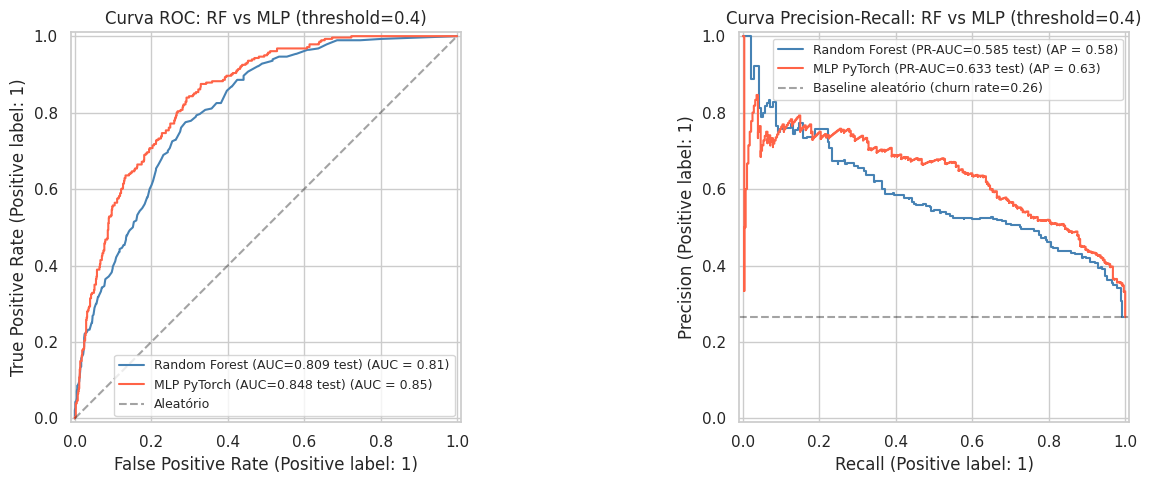

20:29:24 | INFO | Curvas ROC/PR geradas: RF AUC=0.809 (test), MLP AUC=0.848 (test)


In [20]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

# RF para comparação: treinado apenas em X_temp (train+val), sem X_test.
# rf_pipe foi fitado em X completo (para artefato MLflow); usá-lo aqui seria
# data leakage: X_test fez parte do treino, resultando em AUC≈1.000.
rf_pipe_eval = Pipeline([
    ("preprocessor", ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False), cat_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=SEED,
    )),
])
rf_pipe_eval.fit(X_temp, y_temp)

# Curvas ROC e PR: Random Forest vs MLP no mesmo conjunto de teste
rf_test_proba = rf_pipe_eval.predict_proba(X_test)[:, 1]
rf_test_roc_auc = roc_auc_score(y_test, rf_test_proba)
rf_test_pr_auc = average_precision_score(y_test, rf_test_proba)
churn_rate = float(y_test.mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Curva ROC ---
ax_roc = axes[0]
RocCurveDisplay.from_predictions(
    y_test, rf_test_proba,
    name=f"Random Forest (AUC={rf_test_roc_auc:.3f} test)",
    ax=ax_roc, color="steelblue",
)
RocCurveDisplay.from_predictions(
    y_test, test_proba,
    name=f"MLP PyTorch (AUC={mlp_metrics['roc_auc']:.3f} test)",
    ax=ax_roc, color="tomato",
)
ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Aleatório")
ax_roc.set_title(f"Curva ROC: RF vs MLP (threshold={THRESHOLD})")
ax_roc.legend(loc="lower right", fontsize=9)

# --- Curva PR ---
ax_pr = axes[1]
PrecisionRecallDisplay.from_predictions(
    y_test, rf_test_proba,
    name=f"Random Forest (PR-AUC={rf_test_pr_auc:.3f} test)",
    ax=ax_pr, color="steelblue",
)
PrecisionRecallDisplay.from_predictions(
    y_test, test_proba,
    name=f"MLP PyTorch (PR-AUC={mlp_metrics['pr_auc']:.3f} test)",
    ax=ax_pr, color="tomato",
)
ax_pr.axhline(churn_rate, color="k", linestyle="--", alpha=0.4,
              label=f"Baseline aleatório (churn rate={churn_rate:.2f})")
ax_pr.set_title(f"Curva Precision-Recall: RF vs MLP (threshold={THRESHOLD})")
ax_pr.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

log.info(
    "Curvas ROC/PR geradas: RF AUC=%.3f (test), MLP AUC=%.3f (test)",
    rf_test_roc_auc, mlp_metrics['roc_auc'],
)

## 6. Análise de Custo: Falsos Positivos vs Falsos Negativos

**Contexto de negócio:**

| Erro | Situação | Consequência | Custo estimado |
|------|----------|--------------|----------------|
| Falso Negativo (FN) | Modelo não detecta churn real | Cliente cancela sem intervenção | Alto: receita perdida |
| Falso Positivo (FP) | Modelo aciona retenção desnecessariamente | Campanha para quem não cancelaria | Baixo: custo de campanha |

Como FN >> FP em impacto financeiro, o modelo deve **priorizar recall** (minimizar FN).  
O threshold=0.4 (em vez do padrão 0.5) foi escolhido exatamente por esse motivo: aceita mais FP para capturar mais churn real.


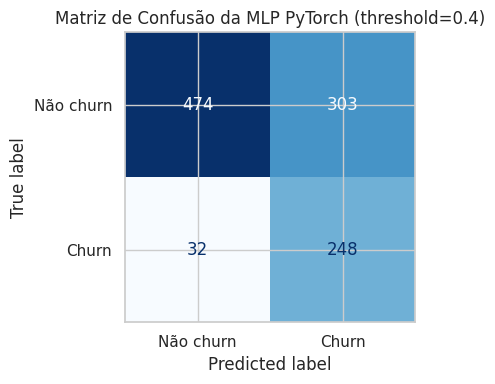

20:29:24 | INFO | Confusão MLP: TN=474, FP=303, FN=32, TP=248


Verdadeiro Negativo = 474  Falso Positivo = 303  Falso Negativo = 32  Verdadeiro Positivo = 248


In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred,
    display_labels=["Não churn", "Churn"],
    colorbar=False,
    cmap="Blues",
    ax=ax,
)
ax.set_title(f"Matriz de Confusão da MLP PyTorch (threshold={THRESHOLD})")
plt.tight_layout()
plt.show()

_tn = int(((test_pred == 0) & (y_test == 0)).sum())
_fp = int(((test_pred == 1) & (y_test == 0)).sum())
_fn = int(((test_pred == 0) & (y_test == 1)).sum())
_tp = int(((test_pred == 1) & (y_test == 1)).sum())
log.info("Confusão MLP: TN=%d, FP=%d, FN=%d, TP=%d", _tn, _fp, _fn, _tp)
print(f"Verdadeiro Negativo = {_tn}  Falso Positivo = {_fp}  Falso Negativo = {_fn}  Verdadeiro Positivo = {_tp}")

In [22]:
# Análise de sensibilidade ao threshold
thresholds = [0.3, 0.4, 0.5]
thresh_rows = []
for t in thresholds:
    pred_t = (test_proba >= t).astype(int)
    thresh_rows.append({
        "Threshold": t,
        "Precisão":  precision_score(y_test, pred_t, zero_division=0),
        "Recall":    recall_score(y_test, pred_t),
        "F1":        f1_score(y_test, pred_t),
        "FP": int(((pred_t == 1) & (y_test == 0)).sum()),
        "FN": int(((pred_t == 0) & (y_test == 1)).sum()),
    })

threshold_df = pd.DataFrame(thresh_rows).set_index("Threshold")
display(threshold_df.round(3))

log.info("Análise de threshold concluída para %s", thresholds)


,Precisão,Recall,F1,FP,FN
Threshold,,,,,
0.3,0.418,0.943,0.579,368,16
0.4,0.450,0.886,0.597,303,32
0.5,0.508,0.807,0.623,219,54


20:29:24 | INFO | Análise de threshold concluída para [0.3, 0.4, 0.5]


### Interpretação de Negócio

- **Threshold 0.3**: recall máximo, mas com mais FPs e mais campanhas desnecessárias.
- **Threshold 0.4** *(escolhido)*: equilíbrio entre recall elevado e precisão aceitável. Justificado pelo custo assimétrico: perder um cliente tem impacto maior do que o custo de uma campanha de retenção desnecessária.
- **Threshold 0.5** (padrão): favorece precisão, mas perde mais clientes reais (mais FNs).

**Decisão:** manter threshold=0.4 para o modelo em produção. A revisão do threshold deve ser feita trimestralmente conforme o custo real de campanha vs. LTV médio do cliente.


## 7. Conclusão

### Visão geral da comparação

Ao longo das Etapas 1 e 2, quatro famílias de modelos foram avaliadas com as mesmas métricas e threshold (0.4):

| Modelo | AUC-ROC | PR-AUC | Recall | F1 | Precisão |
|---|---|---|---|---|---|
| Dummy | ~0.50 | ~0.27 | - | - | - |
| Logistic Regression | 0.845 ± 0.014 | **0.657 ± 0.026** | 0.866 | **0.609** | 0.470 |
| Random Forest | 0.809 ± 0.013 | 0.586 ± 0.023 | 0.601 | 0.579 | **0.558** |
| MLP PyTorch (base) | **0.848** | 0.633 | **0.886** | 0.597 | 0.450 |

> **Nota:** baselines e RF avaliados via CV (5 folds, mean ± std) sobre o dataset completo; MLP avaliada em test set fixo (ponto único). A comparação é **indicativa**, ver nota metodológica da Seção 5 para detalhes.

A MLP lidera em AUC-ROC (0.848 vs 0.845) e Recall (0.886 vs 0.866), mas a Regressão Logística supera a MLP em PR-AUC (0.657 vs 0.633) e F1 (0.609 vs 0.597). O Random Forest tem a melhor Precisão (0.558), porém com Recall de 0.601, abaixo da meta de ≥ 0.70.

### Por que a MLP é o modelo entregue?

A MLP não precisa "vencer" a Regressão Logística para ser a escolha correta: ela precisa ser **adequada ao problema**. Que um modelo linear seja competitivo com uma rede neural em datasets tabulares de tamanho moderado (~7k amostras) é esperado e bem documentado na literatura. Para esse contexto, a MLP é escolhida por ser o modelo-alvo da Etapa 2 e por apresentar o maior Recall (0.886), alinhado com o objetivo de negócio de minimizar clientes perdidos.

A Regressão Logística permanece uma alternativa válida, especialmente por sua PR-AUC superior (0.657 vs 0.633) e maior interpretabilidade. Em datasets maiores ou com interações não-lineares mais complexas, a vantagem de capacidade da MLP tenderia a se tornar mais expressiva.

### Otimização da arquitetura MLP

Dois experimentos adicionais foram conduzidos para tentar melhorar Precisão e F1. A variante final é **selecionada pelo menor `best_val_loss` no conjunto de validação** (critério correto: evita usar o test set para decisão de arquitetura):

| Variante | AUC-ROC | PR-AUC | Recall | F1 | Precisão | Best Val Loss |
|---|---|---|---|---|---|---|
| **MLP Base (64→32)** ✅ | **0.848** | **0.633** | 0.886 | **0.597** | 0.450 | **0.7455** |
| MLP BatchNorm (64→32) | 0.843 | 0.630 | 0.889 | 0.594 | 0.445 | 0.7558 |
| MLP Large (128→64→32) | 0.843 | 0.624 | 0.936 | 0.583 | 0.423 | 0.7621 |

O modelo base apresentou o menor val_loss (0.7455) e o melhor equilíbrio entre PR-AUC e F1. A arquitetura maior ilustrou um comportamento clássico: com capacidade excessiva para o volume de dados disponível, o modelo aprende a maximizar recall às custas de precisão e F1.

### Metas de desempenho

| Métrica | Meta | Resultado | Status |
|---|---|---|---|
| AUC-ROC | ≥ 0.80 | 0.848 | ✅ |
| PR-AUC | ≥ 0.60 | 0.633 | ✅ |
| Recall | ≥ 0.70 | 0.886 | ✅ |
| F1 | ≥ 0.60 | 0.597 | ⚠️ Próximo da meta |
| Precisão | ≥ 0.55 | 0.450 | ❌ Abaixo da meta |

**Sobre a meta de Precisão:** com threshold=0.4, a Regressão Logística ficou em 0.470 e a MLP em 0.450. O Random Forest atingiu 0.558 (dentro da meta), mas com Recall de apenas 0.601, abaixo da meta de ≥ 0.70. Não é possível atingir simultaneamente Precisão ≥ 0.55 e Recall ≥ 0.70 com threshold=0.4 neste dataset. O objetivo de negócio de minimizar clientes perdidos justifica priorizar o Recall, o que implica aceitar precisão menor. A meta de 0.55 foi definida no ML Canvas antes de explorar os dados e mostrou-se otimista para esse nível de recall com churn rate de 26.5%.